# Fundamental solutions and Green functions

We derive and inspect the one-dimensional heat kernel, emphasizing that kernel verification is distributional/source-aware rather than ordinary smooth residual checking at the source.

**Tutorial contract.** This notebook derives the mathematics, asks PDESolve how it recognizes/plans the problem, executes the solver, independently checks the returned mathematics where appropriate, visualizes the solution or its structure, and ends with runnable variations plus exercises.

In [1]:
from pathlib import Path
import sys

# Make a source checkout importable without requiring an editable install.
root = Path.cwd().resolve()
for candidate in [root, *root.parents]:
    if (candidate / "pdesolve").is_dir():
        ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the pdesolve source tree")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pdesolve as pds
from IPython.display import display

sp.init_printing()
print("PDESolve source:", ROOT)
print("SymPy:", sp.__version__)

PDESolve source: /mnt/data/pdesolve_doc22SymPy: 1.14.0

In [2]:
def show_plan(problem, n=6):
    """Display recognizer output and the highest-ranked canonical plan steps."""
    rec = pds.recognize_canonical_problem(problem)
    plan = pds.plan_canonical_problem(problem)
    print("Recognition:", rec)
    print("Top plan steps:")
    for step in plan.steps[:n]:
        print(f"  {step.method:42s} score={step.score}")
    return rec, plan


def rhs_of(solution):
    """Extract the RHS of an Eq result, or return an expression unchanged."""
    return solution.rhs if isinstance(solution, sp.Equality) else solution


def residual(eq, dependent, candidate):
    """Classical residual after replacing the dependent function by candidate."""
    expr = eq.lhs - eq.rhs if isinstance(eq, sp.Equality) else eq
    return sp.simplify(expr.subs(dependent, candidate).doit())

## 1. Heat-kernel DerivationFor $u_t-u_{xx}=0$ on the full line, Fourier transformation in $x$ gives$$\widehat G(k,t)=e^{-k^2t}.$$Inverting yields$$G(x,t;x_0,t_0)=H(t-t_0)\frac{\exp[-(x-x_0)^2/(4(t-t_0))]}{\sqrt{4\pi(t-t_0)}}.$$For $t>t_0$ it satisfies the homogeneous heat equation and has unit mass; distributionally it reproduces a point impulse at $(x_0,t_0)$.

In [3]:
x,t=sp.symbols("x t", real=True)
u=sp.Function("u")
eq=sp.Eq(sp.diff(u(x,t),t)-sp.diff(u(x,t),x,2),0)
problem=pds.build_pde_problem(eq,u(x,t),(x,t))
recognition, plan=show_plan(problem)
kplan=pds.build_kernel_method_plan(problem)
print("Kernel plan:",kplan)

Recognition: (PDERecognitionRecord(family='heat_like', recognized=True, solver_hint='heat_dirichlet_series', tags=('separation_of_variables', 'integral_transform'), metadata={}),)Top plan steps:  constant_coefficient_inverse_operator      score=92  structured_transform                       score=77  heat_dirichlet_series                      score=70  symmetry_reduction                         score=60  post_reduction_auto                        score=48  classification_only                        score=20Kernel plan: KernelMethodPlan(method='kernel_green_function', operator_family='heat_1d', geometry_kind='unspecified_spacetime', boundary_family='free', source_point=(x_0, t_0), metadata={'recognition': {'family': 'heat_1d', 'diffusivity': 1, 'x': x, 't': t, 'source_point': (x_0, t_0), 'has_source': False, 'source_sign': 1}, 'geometry': DomainGeometry(kind='unspecified_spacetime', coordinates=(x, t), extents={}, metadata={}), 'condition_model': ConditionModel(dependent_function=u(x, t

FundamentalSolutionResult kernel_fundamental_solution

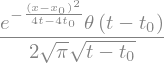

In [4]:
result=pds.solve_fundamental_solution(eq,u(x,t),(x,t))
print(type(result).__name__,result.method)
display(result.solution)

## 2. Verification away from the sourceBecause of the Heaviside factor and point source, the complete identity is distributional. Away from $t=t_0$, however, the smooth Gaussian factor should have zero heat residual. Its spatial integral should be one for positive elapsed time.

In [5]:
x0, tau=sp.symbols("x_0 tau", real=True)
smooth=sp.exp(-(x-x0)**2/(4*tau))/(2*sp.sqrt(sp.pi)*sp.sqrt(tau))
print("Smooth residual:",sp.simplify(sp.diff(smooth,tau)-sp.diff(smooth,x,2)))
print("Mass:",sp.integrate(smooth,(x,-sp.oo,sp.oo),conds="none"))
assert sp.simplify(sp.diff(smooth,tau)-sp.diff(smooth,x,2))==0

Smooth residual: 0Mass: sqrt(tau)/sqrt(polar_lift(tau))

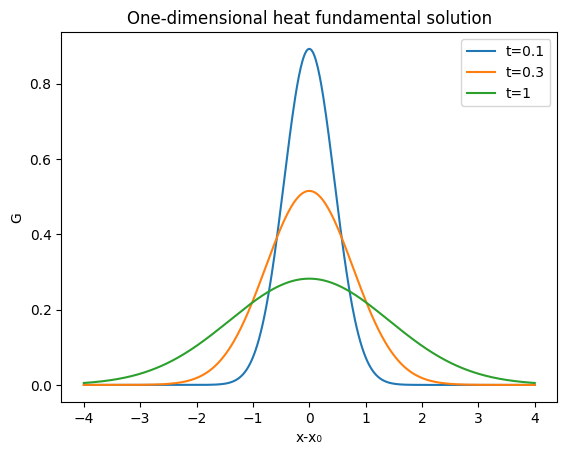

In [6]:
xx=np.linspace(-4,4,500)
fig,ax=plt.subplots()
for tv in [0.1,0.3,1.0]:
    yy=np.exp(-xx**2/(4*tv))/np.sqrt(4*np.pi*tv)
    ax.plot(xx,yy,label=f"t={tv:g}")
ax.set_xlabel("x-x₀"); ax.set_ylabel("G"); ax.set_title("One-dimensional heat fundamental solution"); ax.legend(); plt.show()

## 3. Variation and exercisesUse `solve_green_function` or the advanced Green subsystem for a supported bounded/half-space geometry. Then: (1) verify boundary traces; (2) explain the method-of-images sign for Dirichlet versus Neumann data; (3) compare a fundamental solution with a boundary-adapted Green function.

In [7]:
print("Available kernel APIs:", [name for name in ["solve_fundamental_solution","solve_green_function","execute_kernel_plan"] if hasattr(pds,name)])

Available kernel APIs: ['solve_fundamental_solution', 'solve_green_function', 'execute_kernel_plan']